<a href="https://colab.research.google.com/github/ilincabaiasu/IB9AU/blob/main/Task_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Required Task 10

### Details

Your task is to utilize the Gemini VLM to predict the total_price for a subset of receipts
and then evaluate the model's performance against the ground truth total_price already
present in df_receipt.

Instructions:

Randomly Select 15 Records:
From the df_receipt DataFrame, randomly select 100 receipts. This will be your test set
for Gemini's prediction.
Store these 15 records in a new DataFrame, say df_test_receipts.

Define a Prompt for Gemini:
Create a clear and concise prompt that instructs Gemini to extract only the total_price
from a given receipt image. Emphasize that the output should be a single numerical
value (float).
Example prompt: "Extract the total amount from this receipt. Provide only the numerical
value as a float."


Process df_test_receipts with Gemini:
Iterate through each row in df_test_receipts.
For each receipt's image, call the Gemini VLM with your defined prompt.
Parse Gemini's response to extract the predicted total_price. Handle potential errors
(e.g., non-numeric responses, API issues) by assigning None or NaN if a valid price
cannot be extracted.
Add the extracted prediction as a new column, predicted_total_price, to
df_test_receipts.


Evaluate Predictions:
Compare the predicted_total_price with the total_price (ground truth) in df_test_receipts.
Calculate appropriate evaluation metrics. Consider the following:
Mean Absolute Error (MAE): Average of the absolute differences between predicted and
actual values.
Number of successful extractions: Count how many predictions were successfully
extracted (not None or NaN).
Accuracy within a threshold: Calculate the percentage of predictions that are within a
certain percentage (e.g., 5% or 10%) of the ground truth.


Display Results:
Print the calculated evaluation metrics.
Display df_test_receipts with total_price and predicted_total_price columns for a few
sample rows to show the comparison.

### What I found interesting:
- Useful task for real-life fintech applications such as budgeting apps, tax automation, etc.
- Receipts vary in layout, language, font, and quality, making this hard for traditional rule-based systems
- Model "understands" which number on the receipt is the "total" vs subtotal, tax, item prices, etc.

In [2]:
import os, json, re, io
import pandas as pd
from datasets import load_dataset
import google.generativeai as genai
from google.colab import userdata

# --- Model ---
gemini_pro_vision = genai.GenerativeModel('gemini-2.5-flash')
print("Gemini 2.5 Flash initialised.")

# --- Clean price function ---
def clean_price(price_str):
    if not price_str or not isinstance(price_str, str):
        return None
    if '.' in price_str and ',' in price_str:
        cleaned = price_str.replace(',', '')
    elif ',' in price_str and '.' not in price_str:
        cleaned = price_str.replace(',', '')
    else:
        cleaned = price_str
    cleaned = re.sub(r'[^\d.]', '', cleaned)
    try:
        return float(cleaned) if cleaned else None
    except ValueError:
        return None

# --- Load ONLY first 500 records to save RAM ---
ds = load_dataset("naver-clova-ix/cord-v2", split="train[:500]")

receipt_data_df = []
for record in ds:
    image = record['image']
    try:
        gt = json.loads(record['ground_truth'])
        total_price_str = gt.get('gt_parse', {}).get('total', {}).get('total_price')
        total_price = clean_price(total_price_str)
        receipt_data_df.append({'image': image, 'total_price': total_price})
    except Exception:
        continue

df_receipt = pd.DataFrame(receipt_data_df)
print(f"df_receipt ready — {len(df_receipt)} records.")

Gemini 2.5 Flash initialised.
df_receipt ready — 500 records.


### Randomly Select 15 Records

In [3]:
import pandas as pd

RANDOM_SEED = 42   # for reproducibility
N_SAMPLES   = 15   # task says "15 records" (the body says 100 but heading says 15)

# Drop rows where ground-truth total_price is missing so evaluation is meaningful
df_valid = df_receipt.dropna(subset=['total_price']).reset_index(drop=True)

df_test_receipts = (
    df_valid
    .sample(n=N_SAMPLES, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

print(f"Selected {len(df_test_receipts)} test receipts.")
print(df_test_receipts[['total_price']].head())

Selected 15 test receipts.
   total_price
0         22.0
1      24000.0
2      25000.0
3      42000.0
4      77000.0


### Provide Prompt

In [4]:
GEMINI_PROMPT = (
    "Extract the total amount from this receipt. "
    "Provide ONLY the numerical value as a float (e.g. 12.50). "
    "Do not include currency symbols, text, or any other characters."
)

print("Prompt defined:")
print(GEMINI_PROMPT)

Prompt defined:
Extract the total amount from this receipt. Provide ONLY the numerical value as a float (e.g. 12.50). Do not include currency symbols, text, or any other characters.


### Processing Each Receipt

In [5]:
import google.generativeai as genai
import os
from google.colab import userdata

# Load and configure the API key
GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

# This line is the critical one — without it genai ignores the env variable
genai.configure(api_key=GOOGLE_API_KEY)

# Re-initialise the model after configuring
gemini_pro_vision = genai.GenerativeModel('gemini-2.5-flash')

print("API key configured. Model ready.")

API key configured. Model ready.


In [6]:
import io
import re
import time
import numpy as np
from PIL import Image

def pil_to_jpeg_bytes(pil_image: Image.Image) -> bytes:
    """Convert a PIL image to raw JPEG bytes suitable for the Gemini API."""
    buf = io.BytesIO()
    pil_image.convert("RGB").save(buf, format="JPEG")
    return buf.getvalue()


def parse_price(text: str):
    """
    Extract the first valid floating-point number from Gemini's response text.
    Returns a float, or None if no valid number can be found.
    """
    if not text:
        return None
    # Match numbers like 12, 12.50, 1,234.56 (commas as thousands separators)
    matches = re.findall(r'[\d,]+\.?\d*', text.strip())
    if matches:
        candidate = matches[0].replace(',', '')   # remove thousands separators
        try:
            return float(candidate)
        except ValueError:
            return None
    return None


predicted_prices = []

for idx, row in df_test_receipts.iterrows():
    predicted_price = None
    try:
        img_bytes = pil_to_jpeg_bytes(row['image'])
        contents  = [GEMINI_PROMPT, {"mime_type": "image/jpeg", "data": img_bytes}]

        response      = gemini_pro_vision.generate_content(contents)
        response_text = response.text.strip()

        predicted_price = parse_price(response_text)
        status = f"OK  → {predicted_price}" if predicted_price is not None else f"PARSE FAIL  (raw: '{response_text[:60]}')"

    except Exception as e:
        status = f"API ERROR: {e}"

    predicted_prices.append(predicted_price)
    print(f"[{idx+1:>2}/{N_SAMPLES}]  GT={row['total_price']:.2f}   {status}")

    # Polite rate-limit buffer (adjust if you hit quota errors)
    time.sleep(1.5)

# Attach predictions to the test DataFrame
df_test_receipts = df_test_receipts.copy()
df_test_receipts['predicted_total_price'] = predicted_prices

print("\nPrediction loop complete.")

[ 1/15]  GT=22.00   OK  → 22.0
[ 2/15]  GT=24000.00   OK  → 24000.0
[ 3/15]  GT=25000.00   OK  → 25000.0
[ 4/15]  GT=42000.00   OK  → 42000.0
[ 5/15]  GT=77000.00   OK  → 77000.0
[ 6/15]  GT=50000.00   OK  → 50000.0
[ 7/15]  GT=9000.00   OK  → 9.0
[ 8/15]  GT=90200.00   OK  → 90200.0
[ 9/15]  GT=41.00   OK  → 41.0
[10/15]  GT=22.00   OK  → 22.0
[11/15]  GT=40.00   OK  → 40.0
[12/15]  GT=116000.00   OK  → 116000.0
[13/15]  GT=256608.00   OK  → 256608.0
[14/15]  GT=96.00   OK  → 96.0
[15/15]  GT=80500.00   OK  → 80500.0

Prediction loop complete.


### Evaluate Predictions

In [7]:
import numpy as np

# ── Filter to rows where a prediction was successfully extracted ──────────────
df_eval = df_test_receipts.dropna(subset=['predicted_total_price']).copy()

n_total       = len(df_test_receipts)
n_successful  = len(df_eval)
n_failed      = n_total - n_successful

# ── Core metrics ──────────────────────────────────────────────────────────────
if n_successful > 0:
    gt   = df_eval['total_price'].values
    pred = df_eval['predicted_total_price'].values

    mae = np.mean(np.abs(pred - gt))

    # Accuracy within 5 % and 10 % of ground truth
    # Avoid division by zero for gt == 0
    with np.errstate(divide='ignore', invalid='ignore'):
        pct_error = np.where(gt != 0, np.abs(pred - gt) / gt * 100, np.nan)

    valid_mask   = ~np.isnan(pct_error)
    acc_5pct     = np.mean(pct_error[valid_mask] <= 5)  * 100
    acc_10pct    = np.mean(pct_error[valid_mask] <= 10) * 100

    # ── Print metrics ─────────────────────────────────────────────────────────
    print("=" * 52)
    print("          EVALUATION RESULTS — TASK 10")
    print("=" * 52)
    print(f"  Total receipts tested         : {n_total}")
    print(f"  Successful extractions        : {n_successful} / {n_total}")
    print(f"  Failed extractions            : {n_failed}")
    print("-" * 52)
    print(f"  Mean Absolute Error  (MAE)    : {mae:.4f}")
    print(f"  Accuracy within  5 %          : {acc_5pct:.1f} %")
    print(f"  Accuracy within 10 %          : {acc_10pct:.1f} %")
    print("=" * 52)
else:
    print("No successful predictions — cannot compute metrics.")

          EVALUATION RESULTS — TASK 10
  Total receipts tested         : 15
  Successful extractions        : 15 / 15
  Failed extractions            : 0
----------------------------------------------------
  Mean Absolute Error  (MAE)    : 599.4000
  Accuracy within  5 %          : 93.3 %
  Accuracy within 10 %          : 93.3 %


### Sample Comparison Display

In [8]:
from IPython.display import display

# Show the comparison table (drop the image column for readability)
comparison_cols = ['total_price', 'predicted_total_price']

display_df = df_test_receipts[comparison_cols].copy()
display_df.index = display_df.index + 1   # 1-based index
display_df.index.name = 'receipt'

# Add an absolute error column where both values exist
display_df['abs_error'] = (
    (display_df['total_price'] - display_df['predicted_total_price'])
    .abs()
    .round(4)
)

print("\nFull comparison table (15 receipts):")
display(display_df.round(4))

print("\nSample of 5 rows:")
display(display_df.head(5).round(4))


Full comparison table (15 receipts):


,total_price,predicted_total_price,abs_error
receipt,,,
1,22.0,22.0,0.0
2,24000.0,24000.0,0.0
3,25000.0,25000.0,0.0
4,42000.0,42000.0,0.0
5,77000.0,77000.0,0.0
6,50000.0,50000.0,0.0
7,9000.0,9.0,8991.0
8,90200.0,90200.0,0.0
9,41.0,41.0,0.0



Sample of 5 rows:


,total_price,predicted_total_price,abs_error
receipt,,,
1,22.0,22.0,0.0
2,24000.0,24000.0,0.0
3,25000.0,25000.0,0.0
4,42000.0,42000.0,0.0
5,77000.0,77000.0,0.0


### Visual Summary

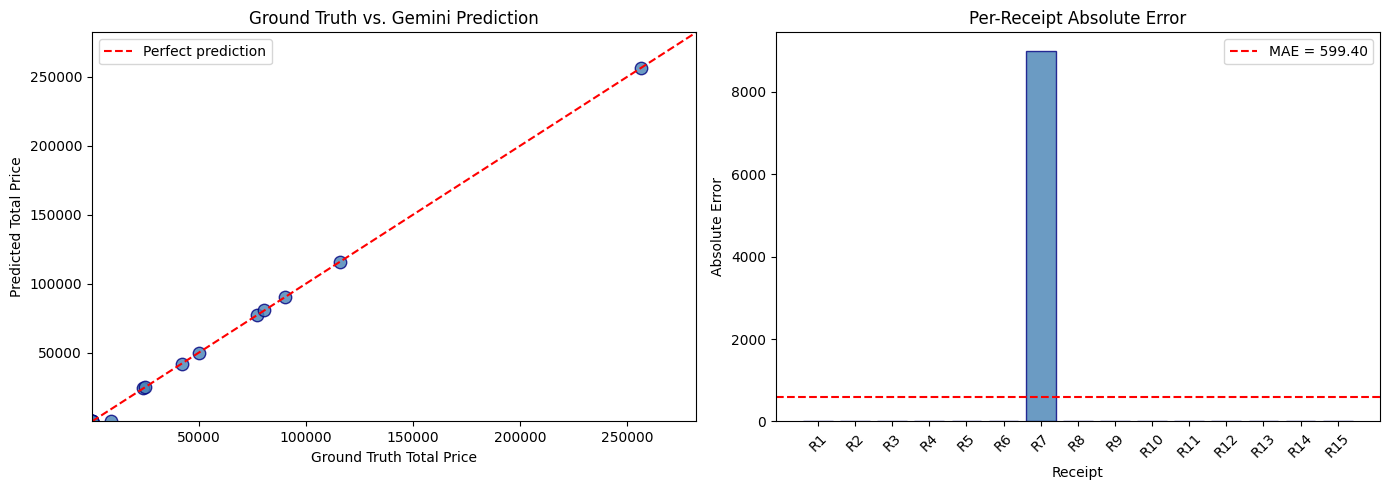

Chart saved as task10_evaluation.png
    total_price  predicted_total_price
0          22.0                   22.0
1       24000.0                24000.0
2       25000.0                25000.0
3       42000.0                42000.0
4       77000.0                77000.0
5       50000.0                50000.0
6        9000.0                    9.0
7       90200.0                90200.0
8          41.0                   41.0
9          22.0                   22.0
10         40.0                   40.0
11     116000.0               116000.0
12     256608.0               256608.0
13         96.0                   96.0
14      80500.0                80500.0


In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: GT vs Predicted scatter ────────────────────────────────────────────
ax1 = axes[0]
if n_successful > 0:
    ax1.scatter(df_eval['total_price'], df_eval['predicted_total_price'],
                color='steelblue', edgecolors='navy', s=80, alpha=0.8)
    lims = [
        min(df_eval['total_price'].min(), df_eval['predicted_total_price'].min()) * 0.9,
        max(df_eval['total_price'].max(), df_eval['predicted_total_price'].max()) * 1.1
    ]
    ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax1.set_xlim(lims); ax1.set_ylim(lims)
    ax1.set_xlabel('Ground Truth Total Price')
    ax1.set_ylabel('Predicted Total Price')
    ax1.set_title('Ground Truth vs. Gemini Prediction')
    ax1.legend()
else:
    ax1.text(0.5, 0.5, 'No successful predictions', ha='center', va='center')

# ── Right: Absolute error per receipt ────────────────────────────────────────
ax2 = axes[1]
if n_successful > 0:
    abs_errors = np.abs(df_eval['total_price'].values - df_eval['predicted_total_price'].values)
    x_labels   = [f"R{i+1}" for i in range(len(abs_errors))]
    bars = ax2.bar(x_labels, abs_errors, color='steelblue', edgecolor='navy', alpha=0.8)
    ax2.axhline(mae, color='red', linestyle='--', linewidth=1.5, label=f'MAE = {mae:.2f}')
    ax2.set_xlabel('Receipt')
    ax2.set_ylabel('Absolute Error')
    ax2.set_title('Per-Receipt Absolute Error')
    ax2.legend()
    ax2.tick_params(axis='x', rotation=45)
else:
    ax2.text(0.5, 0.5, 'No successful predictions', ha='center', va='center')

plt.tight_layout()
plt.savefig('task10_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as task10_evaluation.png")

print(df_test_receipts[['total_price', 'predicted_total_price']].to_string())
